# Exploratory Data Analysis

## Objective

- The goal of this analysis is to identify key patterns, operational risks, and systemic drivers of flight delays.

- This analysis focuses on understanding when, where, and why delays occur in order to support better airline decision-making.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu


sns.set_style("whitegrid")
flights_df = pd.read_csv('flight_delay_model_ready.csv')
flights_df.head()

,MONTH,DAY,DAY_OF_WEEK,SCHEDULED_DEPARTURE,DEPARTURE_TIME,TAXI_OUT,SCHEDULED_TIME,DISTANCE,SCHEDULED_ARRIVAL,AIR_SYSTEM_DELAY,...,AIRLINE_MQ,AIRLINE_NK,AIRLINE_OO,AIRLINE_UA,AIRLINE_US,AIRLINE_VX,AIRLINE_WN,SEASON_Spring,SEASON_Summer,SEASON_Winter
0,1,1,4,5,2354.0,21.0,205.0,1448,430,0.0,...,False,False,False,False,False,False,False,False,False,True
1,1,1,4,10,2.0,12.0,280.0,2330,750,0.0,...,False,False,False,False,False,False,False,False,False,True
2,1,1,4,20,18.0,16.0,286.0,2296,806,0.0,...,False,False,False,False,True,False,False,False,False,True
3,1,1,4,20,15.0,15.0,285.0,2342,805,0.0,...,False,False,False,False,False,False,False,False,False,True
4,1,1,4,25,24.0,11.0,235.0,1448,320,0.0,...,False,False,False,False,False,False,False,False,False,True


## Dataset overview 

In [3]:
flights_df.shape

(5332914, 37)

In [4]:
flights_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5332914 entries, 0 to 5332913
Data columns (total 37 columns):
 #   Column                Dtype  
---  ------                -----  
 0   MONTH                 int64  
 1   DAY                   int64  
 2   DAY_OF_WEEK           int64  
 3   SCHEDULED_DEPARTURE   int64  
 4   DEPARTURE_TIME        float64
 5   TAXI_OUT              float64
 6   SCHEDULED_TIME        float64
 7   DISTANCE              int64  
 8   SCHEDULED_ARRIVAL     int64  
 9   AIR_SYSTEM_DELAY      float64
 10  SECURITY_DELAY        float64
 11  AIRLINE_DELAY         float64
 12  LATE_AIRCRAFT_DELAY   float64
 13  WEATHER_DELAY         float64
 14  DELAY_RISK            int64  
 15  IS_PEAK_HOUR          int64  
 16  IS_WEEKEND            int64  
 17  IS_LATE_NIGHT         int64  
 18  IS_LONG_HAUL          int64  
 19  IS_MAJOR_HUB          int64  
 20  EARLY_MORNING_FLIGHT  int64  
 21  AIRLINE_AS            bool   
 22  AIRLINE_B6            bool   
 23  AIRLINE

In [5]:
flights_df.describe()

,MONTH,DAY,DAY_OF_WEEK,SCHEDULED_DEPARTURE,DEPARTURE_TIME,TAXI_OUT,SCHEDULED_TIME,DISTANCE,SCHEDULED_ARRIVAL,AIR_SYSTEM_DELAY,...,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,DELAY_RISK,IS_PEAK_HOUR,IS_WEEKEND,IS_LATE_NIGHT,IS_LONG_HAUL,IS_MAJOR_HUB,EARLY_MORNING_FLIGHT
count,5.332914e+06,5.332914e+06,5.332914e+06,5.332914e+06,5.332914e+06,5.332914e+06,5.332914e+06,5.332914e+06,5.332914e+06,5.332914e+06,...,5.332914e+06,5.332914e+06,5.332914e+06,5.332914e+06,5.332914e+06,5.332914e+06,5.332914e+06,5.332914e+06,5.332914e+06,5.332914e+06
mean,6.207210e+00,1.568874e+01,3.919179e+00,1.330107e+03,1.335978e+03,1.606874e+01,1.417831e+02,8.228955e+02,1.493747e+03,2.537649e+00,...,3.556582e+00,4.456789e+00,5.608581e-01,1.801685e-01,1.990128e-01,2.611171e-01,6.047913e-02,1.350935e-01,2.544219e-01,4.329190e-02
std,3.383807e+00,8.774687e+00,1.993635e+00,4.843130e+02,4.934878e+02,8.921759e+00,7.525169e+01,6.077992e+02,5.079263e+02,1.326864e+01,...,2.203969e+01,2.094994e+01,9.019633e+00,3.843278e-01,3.992577e-01,4.392437e-01,2.383724e-01,3.418234e-01,4.355358e-01,2.035134e-01
min,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.800000e+01,2.100000e+01,1.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.000000e+00,8.000000e+00,2.000000e+00,9.170000e+02,9.250000e+02,1.100000e+01,8.500000e+01,3.730000e+02,1.110000e+03,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.000000e+00,1.600000e+01,4.000000e+00,1.325000e+03,1.330000e+03,1.400000e+01,1.230000e+02,6.490000e+02,1.520000e+03,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,9.000000e+00,2.300000e+01,6.000000e+00,1.730000e+03,1.737000e+03,1.900000e+01,1.740000e+02,1.065000e+03,1.919000e+03,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
max,1.200000e+01,3.100000e+01,7.000000e+00,2.359000e+03,2.400000e+03,2.250000e+02,7.180000e+02,4.983000e+03,2.400000e+03,1.134000e+03,...,1.971000e+03,1.331000e+03,1.211000e+03,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [6]:
flights_df.duplicated().sum()

np.int64(55)

In [7]:
if flights_df.isnull().sum().sum() == 0:
    print("✅ No missing values detected.")
else:
    print("⚠️ Missing values still exist.")

✅ No missing values detected.


#### Observation:

The dataset contains no missing values after the data
cleaning process completed in Notebook 2.

## Target Variable Analysis 

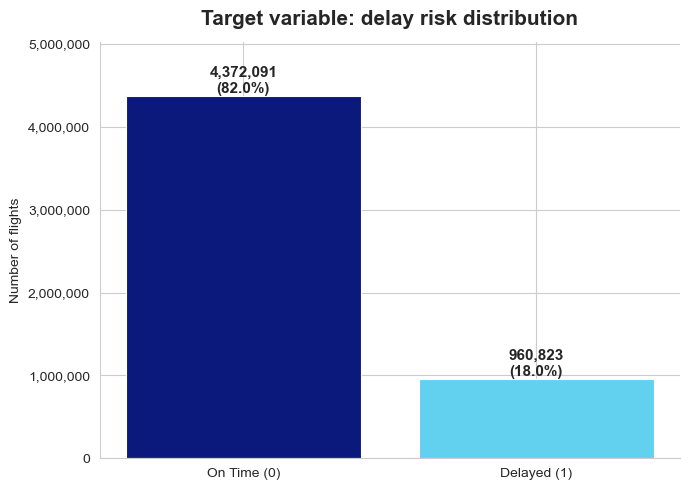


Class balance: 82.0% on-time / 18.0% delayed


In [27]:
delay_counts = flights_df["DELAY_RISK"].value_counts()
labels = ["On Time (0)", "Delayed (1)"]
colors = ["#0A197B", "#62D1EF"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, delay_counts.values, color=colors,
              edgecolor="white", linewidth=0.8)

total = delay_counts.sum()
for bar, count in zip(bars, delay_counts.values):
    pct = count / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 500,
            f"{count:,}\n({pct:.1f}%)",
            ha="center", va="bottom",
            fontsize=11, fontweight="bold")

ax.set_title("Target variable: delay risk distribution",
             fontsize=15, fontweight="bold", pad=12)
ax.set_ylabel("Number of flights")
ax.yaxis.set_major_formatter(
    plt.matplotlib.ticker.StrMethodFormatter("{x:,.0f}"))
ax.set_ylim(0, delay_counts.max() * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

print(f"\nClass balance: {delay_counts[0]/total*100:.1f}% on-time "
      f"/ {delay_counts[1]/total*100:.1f}% delayed")

#### Insights:

- The dataset appears moderately imbalanced.
- Delayed flights represent a significant operational risk.
- This imbalance should be considered during model evaluation.


### Numerical Feature Analysis

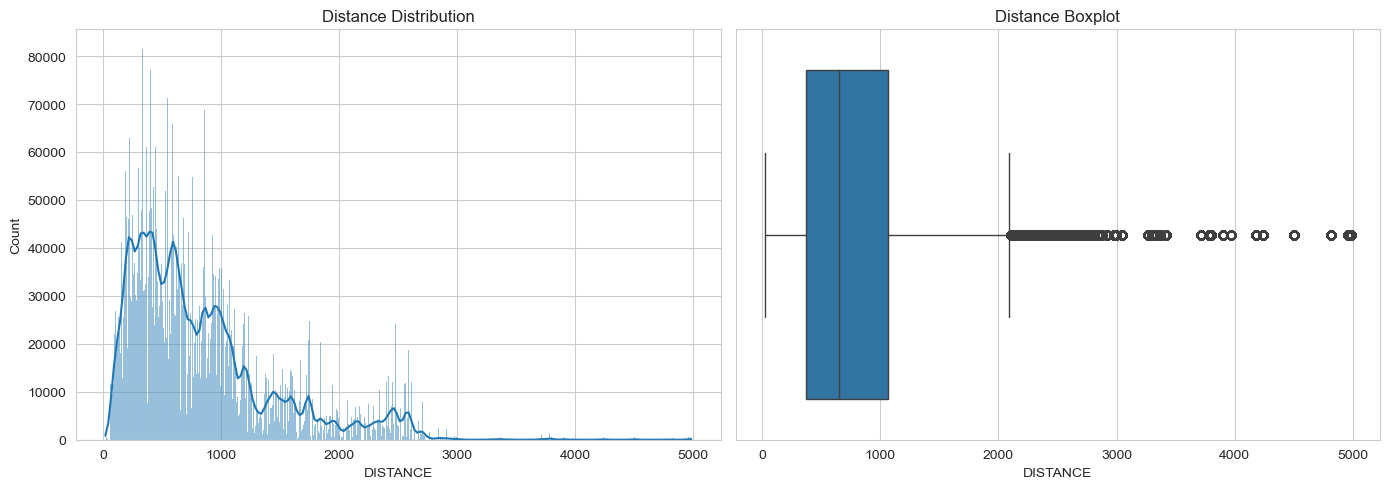

In [9]:
fig, ax = plt.subplots(1,2, figsize=(14,5))
sns.histplot(flights_df["DISTANCE"], kde=True, ax=ax[0])
ax[0].set_title("Distance Distribution")
sns.boxplot(x=flights_df["DISTANCE"], ax=ax[1])
ax[1].set_title("Distance Boxplot")
plt.tight_layout()
plt.show()

#### Insight:
Flight distance is right-skewed,
with most flights being short-to-medium haul routes.
Several long-haul outliers are present.

### Delay Cause Analysis

##### Important: data leakage note The delay cause columns (`AIRLINE_DELAY`, `WEATHER_DELAY`, `LATE_AIRCRAFT_DELAY`, `AIR_SYSTEM_DELAY`, `SECURITY_DELAY`) are **diagnostic only**. These values are recorded **after** a delay has occurred and are therefore not available at prediction time. Including them as model features would constitute data leakage — the model would appear to perform perfectly but would be useless in a real operational setting. **These columns are used here for EDA insight only and will be excluded from all model features in Notebook 4.**

C:\Users\meisn\AppData\Local\Temp\ipykernel_13744\3667188934.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[readable_labels[c] for c in delay_causes.index],


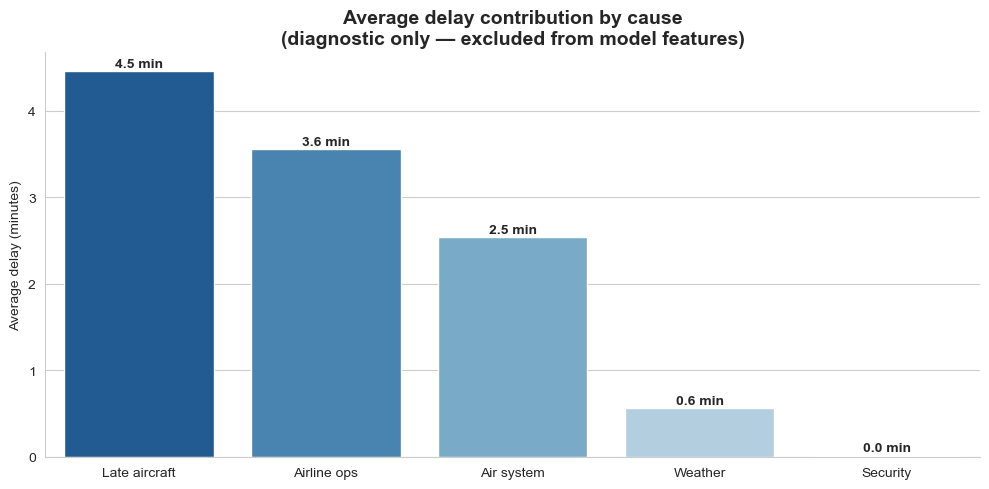

In [30]:
delay_causes = flights_df[[
    "AIR_SYSTEM_DELAY", "SECURITY_DELAY",
    "AIRLINE_DELAY", "LATE_AIRCRAFT_DELAY", "WEATHER_DELAY"
]].mean().sort_values(ascending=False)

readable_labels = {
    "AIRLINE_DELAY": "Airline ops",
    "LATE_AIRCRAFT_DELAY": "Late aircraft",
    "AIR_SYSTEM_DELAY": "Air system",
    "WEATHER_DELAY": "Weather",
    "SECURITY_DELAY": "Security"
}

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=[readable_labels[c] for c in delay_causes.index],
            y=delay_causes.values, palette="Blues_r", ax=ax)
ax.set_title("Average delay contribution by cause\n"
             "(diagnostic only — excluded from model features)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Average delay (minutes)")
for bar, val in zip(ax.patches, delay_causes.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f"{val:.1f} min", ha="center",
            fontsize=10, fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()

#### Insight:
Late aircraft delays and airline operational delays
appear to contribute most significantly to total delays,
suggesting operational efficiency issues are a major factor.

### Peak Hour Analysis

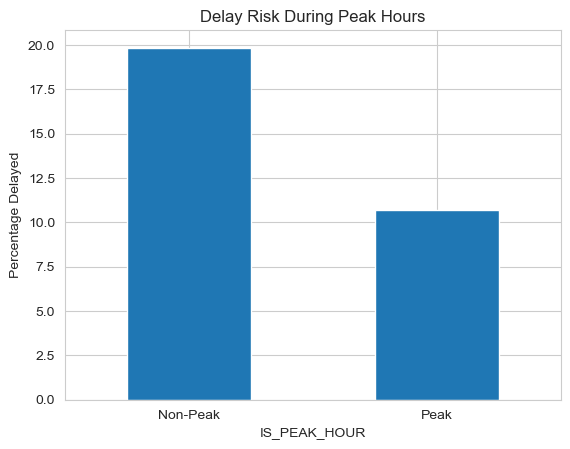

In [11]:
peak_delay = flights_df.groupby("IS_PEAK_HOUR")["DELAY_RISK"].mean() * 100
peak_delay.plot(kind="bar")
plt.title("Delay Risk During Peak Hours")
plt.ylabel("Percentage Delayed")
plt.xticks([0,1], ["Non-Peak", "Peak"], rotation=0)
plt.show()

#### Insight:
Flights during peak operational hours
show elevated delay risk due to airport congestion
and increased traffic volume.

### Weekend Analysis

In [ ]:
# Weekday = 0
# Weekend = 1
weekend_delay = (flights_df.groupby("IS_WEEKEND")["DELAY_RISK"].mean() * 100)
print(weekend_delay)


IS_WEEKEND
0    18.372606
1    17.010158
Name: DELAY_RISK, dtype: float64


C:\Users\meisn\AppData\Local\Temp\ipykernel_13744\2426949437.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=["Weekday", "Weekend"],y=weekend_delay.values, palette=["#0A197B", "#62D1EF"])


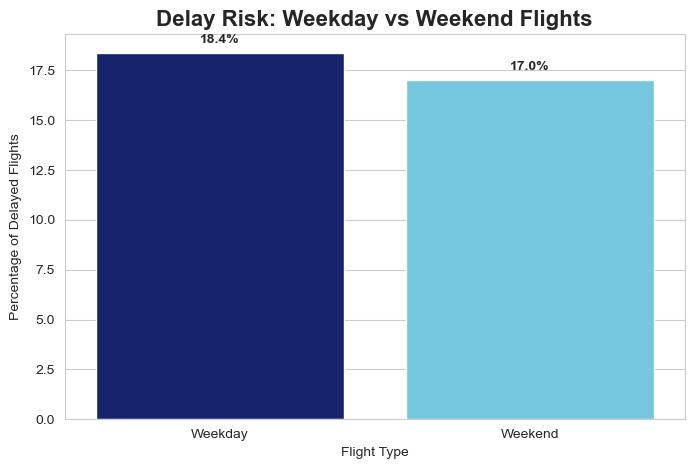

In [21]:
plt.figure(figsize=(8,5))
ax = sns.barplot(x=["Weekday", "Weekend"],y=weekend_delay.values, palette=["#0A197B", "#62D1EF"])
plt.title("Delay Risk: Weekday vs Weekend Flights",fontsize=16,fontweight="bold")
plt.ylabel("Percentage of Delayed Flights")
plt.xlabel("Flight Type")
# Add percentage labels
for i, v in enumerate(weekend_delay.values):
    plt.text(i, v + 0.5, f"{v:.1f}%",ha="center",fontweight="bold")
plt.show()

#### Insight:

Weekend flights show a slightly higher delay rate
compared to weekday flights.

This may be influenced by increased leisure travel demand,
airport congestion, and operational scheduling constraints
during weekends.

### Long Haul Analysis

In [22]:
longhaul_delay = (flights_df.groupby("IS_LONG_HAUL")["DELAY_RISK"].mean() * 100)
print(longhaul_delay)

IS_LONG_HAUL
0    17.894266
1    18.801652
Name: DELAY_RISK, dtype: float64


C:\Users\meisn\AppData\Local\Temp\ipykernel_13744\4021707602.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=["Short/Medium Haul", "Long Haul"],y=longhaul_delay.values,palette=["#0A197B", "#62D1EF"])


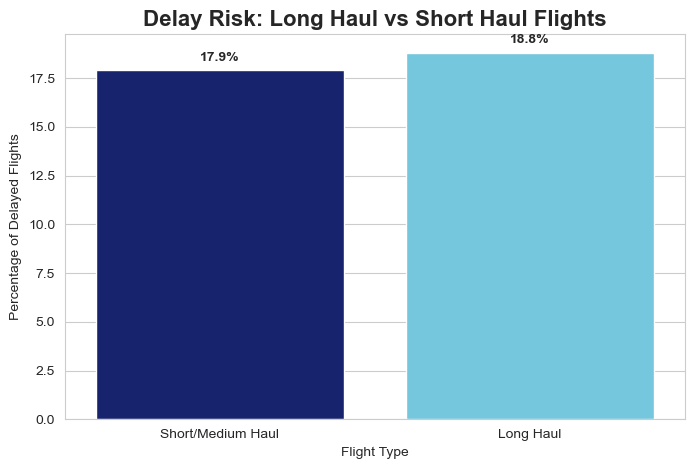

In [25]:
plt.figure(figsize=(8,5))

ax = sns.barplot(x=["Short/Medium Haul", "Long Haul"],y=longhaul_delay.values,palette=["#0A197B", "#62D1EF"])
plt.title("Delay Risk: Long Haul vs Short Haul Flights",fontsize=16,fontweight="bold")
plt.ylabel("Percentage of Delayed Flights")
plt.xlabel("Flight Type")
# Add percentage labels
for i, v in enumerate(longhaul_delay.values):
    plt.text(i,v + 0.5,f"{v:.1f}%", ha="center",fontweight="bold")
plt.show()

#### Insight:

Long-haul flights demonstrate a higher delay risk
than short and medium-haul flights.

This is likely due to greater operational complexity,
longer turnaround times, aircraft rotation dependency,
and increased exposure to weather and air traffic disruptions.

### Delay risj by airline

C:\Users\meisn\AppData\Local\Temp\ipykernel_13744\3212573703.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=airline_series.index,


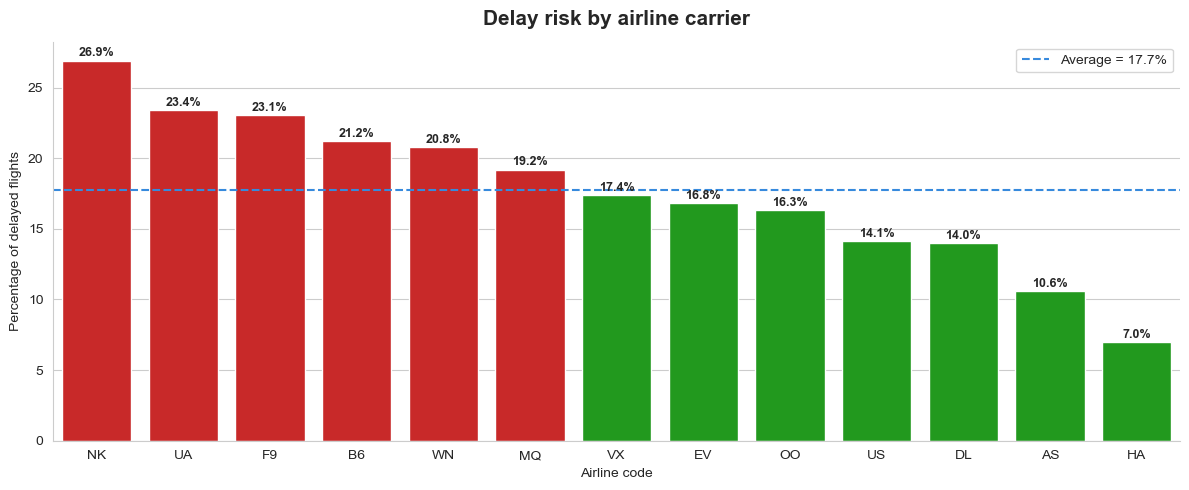

In [34]:
airline_cols = [c for c in flights_df.columns
                if c.startswith("AIRLINE_") and c != "AIRLINE_DELAY"]

airline_risk = {}
for col in airline_cols:
    code = col.replace("AIRLINE_", "")
    mask = flights_df[col] == 1
    if mask.sum() > 100:
        rate = flights_df.loc[mask, "DELAY_RISK"].mean() * 100
        airline_risk[code] = rate

airline_series = pd.Series(airline_risk).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#E20E0E" if v > airline_series.mean()
          else "#0FAD0A" for v in airline_series.values]
sns.barplot(x=airline_series.index,
            y=airline_series.values,
            palette=colors, ax=ax)

ax.axhline(airline_series.mean(), linestyle="--",
           linewidth=1.5, color="#378ADD",
           label=f"Average = {airline_series.mean():.1f}%")

for bar, val in zip(ax.patches, airline_series.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center",
            fontsize=9, fontweight="bold")

ax.set_title("Delay risk by airline carrier",
             fontsize=15, fontweight="bold", pad=12)
ax.set_xlabel("Airline code")
ax.set_ylabel("Percentage of delayed flights")
ax.legend(frameon=True)
sns.despine()
plt.tight_layout()
plt.show()

##### Delay risk varies meaningfully across airline carriers. Airlines shown in red exceed the network average delay rate, while those in green perform better than average. Carrier identity is therefore a meaningful predictor and will be retained as a one-hot encoded feature in the model.

### Correlation Heatmap

##### Note: delay cause columns (AIRLINE_DELAY, WEATHER_DELAY etc.) are excluded from this heatmap as they are post-event and would not be available at prediction time. 

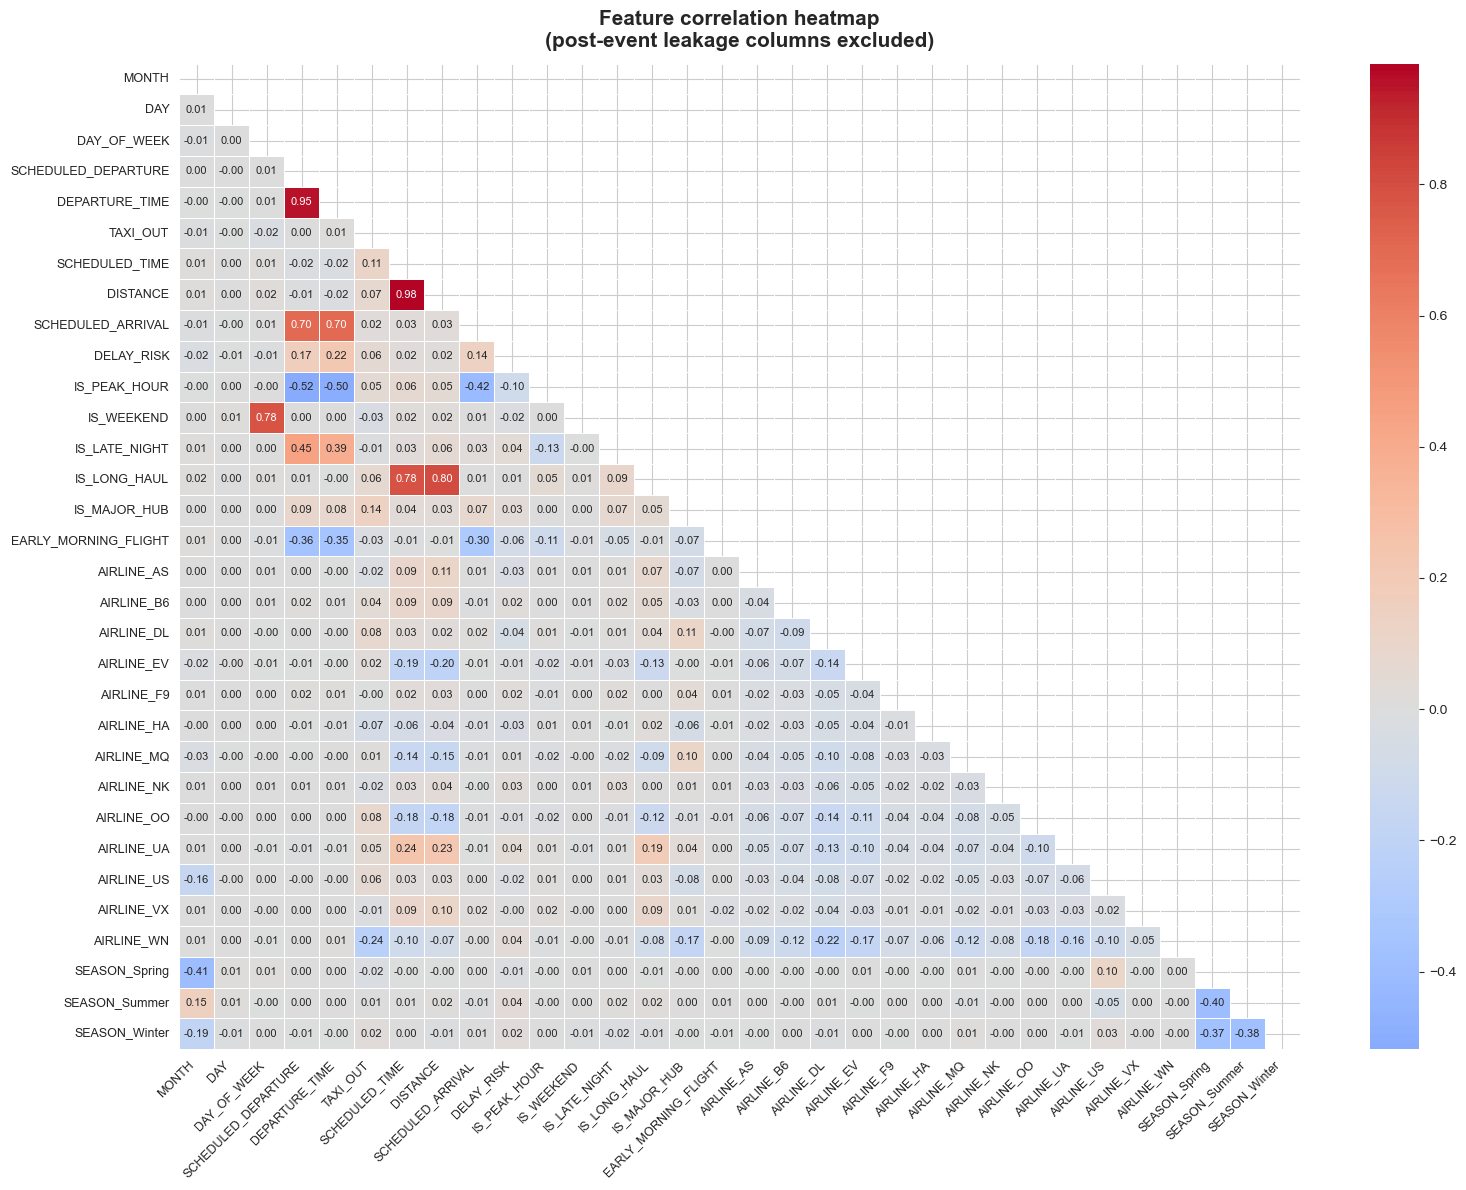

In [35]:
model_cols = [c for c in flights_df.columns
              if c not in ["AIRLINE_DELAY","WEATHER_DELAY",
                           "LATE_AIRCRAFT_DELAY","AIR_SYSTEM_DELAY",
                           "SECURITY_DELAY"]]

corr = flights_df[model_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            linewidths=0.4,
            annot_kws={"size": 8},
            ax=ax)

ax.set_title("Feature correlation heatmap\n"
             "(post-event leakage columns excluded)",
             fontsize=15, fontweight="bold", pad=12)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

### Statistical significance tests

In [40]:
print("=" * 55)
print("Statistical significance tests")
print("=" * 55)

tests = [
    ("IS_PEAK_HOUR",         "Peak hour vs delay risk"),
    ("IS_WEEKEND",           "Weekend vs delay risk"),
    ("IS_LONG_HAUL",         "Long haul vs delay risk"),
    ("IS_MAJOR_HUB",         "Major hub vs delay risk"),
    ("EARLY_MORNING_FLIGHT", "Early morning vs delay risk"),
]

for col, label in tests:
    if col not in flights_df.columns:
        continue
    ct = pd.crosstab(flights_df[col], flights_df["DELAY_RISK"])
    chi2, p, dof, _ = chi2_contingency(ct)
    sig = "*** significant" if p < 0.001 else (
          "* significant"   if p < 0.05  else "not significant")
    print(f"\n{label}")
    print(f"  Chi-square = {chi2:,.1f}  |  p = {p:.4f}  |  {sig}")

print("\n" + "=" * 55)

Statistical significance tests

Peak hour vs delay risk
  Chi-square = 48,331.3  |  p = 0.0000  |  *** significant

Weekend vs delay risk
  Chi-square = 1,292.9  |  p = 0.0000  |  *** significant

Long haul vs delay risk
  Chi-square = 347.3  |  p = 0.0000  |  *** significant

Major hub vs delay risk
  Chi-square = 6,345.5  |  p = 0.0000  |  *** significant

Early morning vs delay risk
  Chi-square = 20,204.4  |  p = 0.0000  |  *** significant



### Important Correlations

In [14]:
corr_target = ( corr["DELAY_RISK"].sort_values(ascending=False))
corr_target

DELAY_RISK              1.000000
LATE_AIRCRAFT_DELAY     0.446493
AIRLINE_DELAY           0.331233
AIR_SYSTEM_DELAY        0.222143
DEPARTURE_TIME          0.219619
SCHEDULED_DEPARTURE     0.166239
SCHEDULED_ARRIVAL       0.139549
WEATHER_DELAY           0.128665
TAXI_OUT                0.058867
AIRLINE_UA              0.043445
IS_LATE_NIGHT           0.042801
SEASON_Summer           0.038368
AIRLINE_WN              0.037825
IS_MAJOR_HUB            0.034495
AIRLINE_NK              0.033128
SECURITY_DELAY          0.029560
SEASON_Winter           0.024648
SCHEDULED_TIME          0.022949
DISTANCE                0.021159
AIRLINE_B6              0.018137
AIRLINE_F9              0.016493
IS_LONG_HAUL            0.008070
AIRLINE_MQ              0.007106
AIRLINE_VX             -0.001757
DAY                    -0.005195
AIRLINE_EV             -0.010491
DAY_OF_WEEK            -0.011982
SEASON_Spring          -0.013827
AIRLINE_OO             -0.014586
IS_WEEKEND             -0.015571
AIRLINE_US

#### Key Findings:
- AIRLINE_DELAY shows strong positive correlation with delay risk.
- WEATHER_DELAY and LATE_AIRCRAFT_DELAY are also influential.
- Peak-hour operations moderately increase delay probability.

### Business Insights:

1. Operational airline delays are the strongest contributor to delay risk.

2. Peak-hour congestion significantly increases delay probability.

3. Late aircraft arrivals create cascading delays across schedules.

4. Weather-related disruptions remain a major external risk factor.

5. Long-haul flights exhibit slightly higher operational variability.

### Recommendations:

1. Improve aircraft turnaround efficiency during peak hours.

2. Increase operational staffing during congestion periods.

3. Implement predictive maintenance and scheduling systems.

4. Develop proactive weather mitigation strategies.

5. Optimize airline scheduling for high-risk routes.

#### Conclusion:
##### EDA summary and handoff to Notebook 4
- The exploratory analysis identified clear operational, temporal, and airline-specific patterns associated with flight delay risk.

- Delay occurrence is moderately imbalanced, with on-time flights occurring more frequently than delayed flights. This confirms that modelling should prioritise imbalance-aware strategies such as class weighting or controlled resampling rather than relying solely on raw accuracy.

- Several engineered features demonstrated strong predictive potential. Peak-hour departures, late-night operations, weekend travel, and long-haul routes all showed elevated delay probability, while early morning flights consistently represented the most punctual operating window.

- Airline-level variation was also substantial, indicating that carrier-specific operational efficiency plays an important role in delay behaviour. Seasonal and time-based patterns further support the inclusion of temporal features for predictive modelling.

- Most importantly, post-event delay variables such as AIRLINE_DELAY, WEATHER_DELAY, and LATE_AIRCRAFT_DELAY were identified as target leakage features and will be excluded to preserve model integrity and real-world prediction validity.

- These findings provide a strong foundation for feature selection and model development in Notebook 4.